# Heart Disease Prediction using Machine Learning

## Project Overview

Heart disease is one of the leading causes of death worldwide. Early prediction can help healthcare professionals identify high-risk patients and provide timely treatment.

In this project, machine learning models are developed to predict whether a patient is likely to have heart disease based on various clinical attributes. The project includes data preprocessing, exploratory data analysis (EDA), model training, hyperparameter tuning, model evaluation, explainable AI using SHAP, and prediction on new patient data.

---

### Objectives

- Analyze the heart disease dataset.
- Perform data preprocessing and exploratory data analysis.
- Train and compare multiple machine learning models.
- Optimize model performance using hyperparameter tuning.
- Interpret model predictions using SHAP explainability.
- Predict heart disease risk for new patient data.

---

### Technologies Used

- Python
- Pandas
- NumPy
- Matplotlib
- Seaborn
- Scikit-learn
- SHAP
- SQLite
- Jupyter Notebook

In [ ]:
## 1. Import Libraries

import pandas as pd
import numpy as np
import os

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, GridSearchCV, cross_val_score
from sklearn.preprocessing import StandardScaler

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier, StackingClassifier

from sklearn.metrics import (
    accuracy_score,
    confusion_matrix,
    classification_report,
    cross_val_score,
    roc_auc_score
)

import shap
import sqlite3
import joblib

c:\Users\LEENA ASMITHA\AppData\Local\Programs\Python\Python314\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## 2. Load Dataset

In [ ]:

df = pd.read_csv("myproject/gold/clean_data.csv")

# Display the first 5 rows
print(df.head())

# Display summary statistics
print(df.describe())

   age  sex  cp  trestbps  chol  fbs  restecg  thalach  exang  oldpeak  slope  \
0   52    1   0       125   212    0        1      168      0      1.0      2   
1   53    1   0       140   203    1        0      155      1      3.1      0   
2   70    1   0       145   174    0        1      125      1      2.6      0   
3   61    1   0       148   203    0        1      161      0      0.0      2   
4   62    0   0       138   294    1        1      106      0      1.9      1   

   ca  thal  target  
0   2     3       0  
1   0     3       0  
2   0     3       0  
3   1     3       0  
4   3     2       0  
             age         sex          cp    trestbps        chol         fbs  \
count  302.00000  302.000000  302.000000  302.000000  302.000000  302.000000   
mean    54.42053    0.682119    0.963576  131.602649  246.500000    0.149007   
std      9.04797    0.466426    1.032044   17.563394   51.753489    0.356686   
min     29.00000    0.000000    0.000000   94.000000  126.000

## 3. Data Cleaning & Preprocessing

In [ ]:

# File paths
RAW_FILE = "myproject/raw/heart.csv"
OUTPUT_DIR = "myproject/gold"
OUTPUT_FILE = os.path.join(OUTPUT_DIR, "clean_data.csv")

# Load data
df = pd.read_csv(RAW_FILE)

print("Original Shape:", df.shape)

# Remove duplicates
df.drop_duplicates(inplace=True)

print("Cleaned Shape:", df.shape)

# Create gold folder if it doesn't exist
os.makedirs(OUTPUT_DIR, exist_ok=True)

# Save cleaned data
df.to_csv(OUTPUT_FILE, index=False)

print("Cleaned data saved to:", OUTPUT_FILE)
print("ETL Pipeline Completed Successfully!")

Original Shape: (1025, 14)
Cleaned Shape: (302, 14)
Cleaned data saved to: myproject/gold\clean_data.csv
ETL Pipeline Completed Successfully!


## 4. Storing Processed Data in SQLite Database

In [ ]:

# Load cleaned dataset
df = pd.read_csv("myproject/gold/clean_data.csv")

# Connect to SQLite database
conn = sqlite3.connect("heart_disease.db")
cursor = conn.cursor()

cursor.execute("PRAGMA foreign_keys = ON")

# Create tables
cursor.executescript("""
CREATE TABLE IF NOT EXISTS PATIENT (
    patient_id INTEGER PRIMARY KEY AUTOINCREMENT,
    age INTEGER NOT NULL CHECK(age BETWEEN 1 AND 120),
    sex INTEGER NOT NULL CHECK(sex IN (0,1))
);

CREATE TABLE IF NOT EXISTS VITALS (
    vitals_id INTEGER PRIMARY KEY AUTOINCREMENT,
    patient_id INTEGER NOT NULL,
    trestbps INTEGER CHECK(trestbps > 0),
    chol INTEGER CHECK(chol > 0),
    fbs INTEGER CHECK(fbs IN (0,1)),
    FOREIGN KEY(patient_id) REFERENCES PATIENT(patient_id)
);

CREATE TABLE IF NOT EXISTS ECG_RESULTS (
    ecg_id INTEGER PRIMARY KEY AUTOINCREMENT,
    patient_id INTEGER NOT NULL,
    restecg INTEGER,
    thalach INTEGER,
    exang INTEGER,
    FOREIGN KEY(patient_id) REFERENCES PATIENT(patient_id)
);

CREATE TABLE IF NOT EXISTS HEART_ASSESSMENT (
    assessment_id INTEGER PRIMARY KEY AUTOINCREMENT,
    patient_id INTEGER NOT NULL,
    cp INTEGER,
    oldpeak REAL,
    slope INTEGER,
    ca INTEGER,
    thal INTEGER,
    FOREIGN KEY(patient_id) REFERENCES PATIENT(patient_id)
);

CREATE TABLE IF NOT EXISTS DIAGNOSIS (
    diagnosis_id INTEGER PRIMARY KEY AUTOINCREMENT,
    patient_id INTEGER NOT NULL,
    target INTEGER,
    FOREIGN KEY(patient_id) REFERENCES PATIENT(patient_id)
);
""")

# Insert records
for _, row in df.iterrows():

    cursor.execute("""
        INSERT INTO PATIENT(age, sex)
        VALUES (?, ?)
    """, (int(row["age"]), int(row["sex"])))

    patient_id = cursor.lastrowid

    cursor.execute("""
        INSERT INTO VITALS
        (patient_id, trestbps, chol, fbs)
        VALUES (?, ?, ?, ?)
    """, (
        patient_id,
        int(row["trestbps"]),
        int(row["chol"]),
        int(row["fbs"])
    ))

    cursor.execute("""
        INSERT INTO ECG_RESULTS
        (patient_id, restecg, thalach, exang)
        VALUES (?, ?, ?, ?)
    """, (
        patient_id,
        int(row["restecg"]),
        int(row["thalach"]),
        int(row["exang"])
    ))

    cursor.execute("""
        INSERT INTO HEART_ASSESSMENT
        (patient_id, cp, oldpeak, slope, ca, thal)
        VALUES (?, ?, ?, ?, ?, ?)
    """, (
        patient_id,
        int(row["cp"]),
        float(row["oldpeak"]),
        int(row["slope"]),
        int(row["ca"]),
        int(row["thal"])
    ))

    cursor.execute("""
        INSERT INTO DIAGNOSIS
        (patient_id, target)
        VALUES (?, ?)
    """, (
        patient_id,
        int(row["target"])
    ))

conn.commit()
conn.close()

print("Database created and data loaded successfully!")

Database created and data loaded successfully!


## 5. Exploratory Data Analysis (EDA)

In [ ]:

# Load cleaned dataset
df = pd.read_csv("myproject/gold/clean_data.csv")

# 1. Display dataset information
print("DATASET INFORMATION")
print("-" * 50)
df.info()

# 2. Display descriptive statistics
print("\nDESCRIPTIVE STATISTICS")
print("-" * 50)
print(df.describe())

# 3. Show value counts for categorical columns
categorical_cols = [
    'sex',
    'cp',
    'fbs',
    'restecg',
    'exang',
    'slope',
    'thal',
    'target'
]

print("\nCATEGORICAL COLUMN VALUE COUNTS")
print("-" * 50)

for col in categorical_cols:
    print(f"\nValue Counts for '{col}'")
    print("-" * 30)
    print(df[col].value_counts())

# 4. Calculate count and percentage of missing values
print("\nMISSING VALUES ANALYSIS")
print("-" * 50)

missing_count = df.isnull().sum()
missing_percentage = (missing_count / len(df)) * 100

missing_df = pd.DataFrame({
    'Missing Count': missing_count,
    'Missing Percentage (%)': missing_percentage.round(2)
})

print(missing_df)

# Optional: Display dataset shape
print("\nDATASET SHAPE")
print("-" * 50)
print(f"Rows: {df.shape[0]}")
print(f"Columns: {df.shape[1]}")

DATASET INFORMATION
--------------------------------------------------
<class 'pandas.DataFrame'>
RangeIndex: 302 entries, 0 to 301
Data columns (total 14 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       302 non-null    int64  
 1   sex       302 non-null    int64  
 2   cp        302 non-null    int64  
 3   trestbps  302 non-null    int64  
 4   chol      302 non-null    int64  
 5   fbs       302 non-null    int64  
 6   restecg   302 non-null    int64  
 7   thalach   302 non-null    int64  
 8   exang     302 non-null    int64  
 9   oldpeak   302 non-null    float64
 10  slope     302 non-null    int64  
 11  ca        302 non-null    int64  
 12  thal      302 non-null    int64  
 13  target    302 non-null    int64  
dtypes: float64(1), int64(13)
memory usage: 33.2 KB

DESCRIPTIVE STATISTICS
--------------------------------------------------
             age         sex          cp    trestbps        chol         fbs  \
coun

## 6. Data Visualization

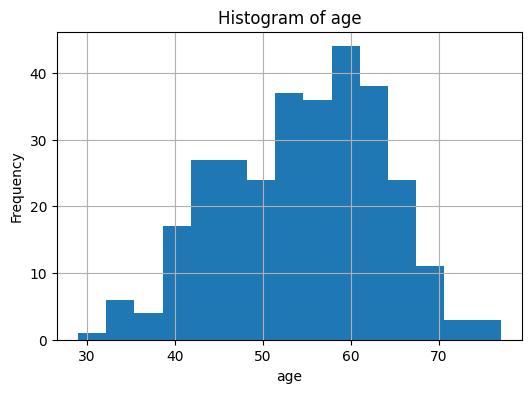

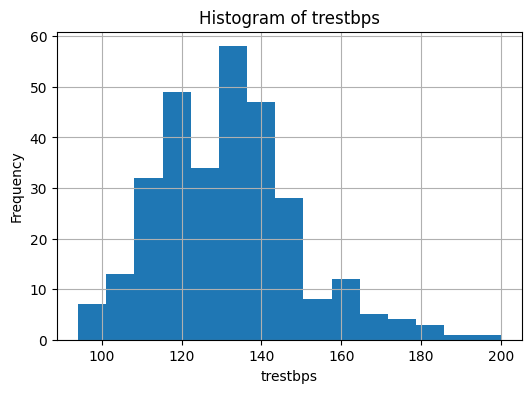

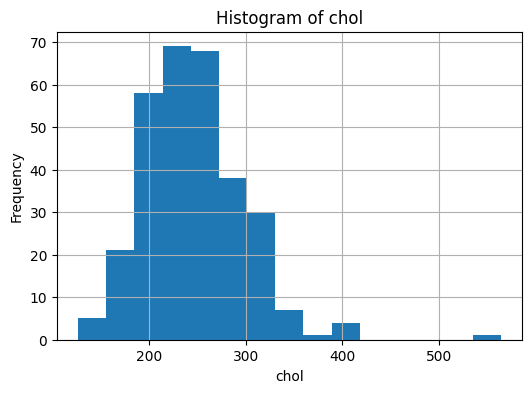

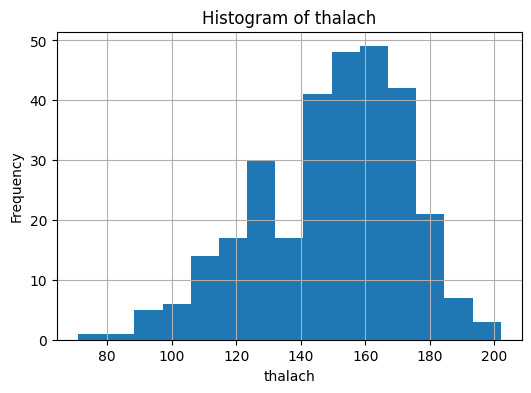

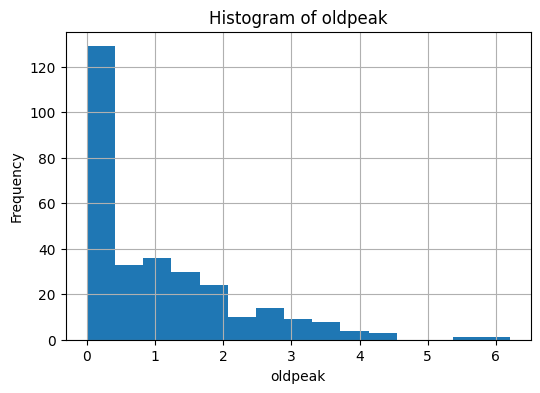

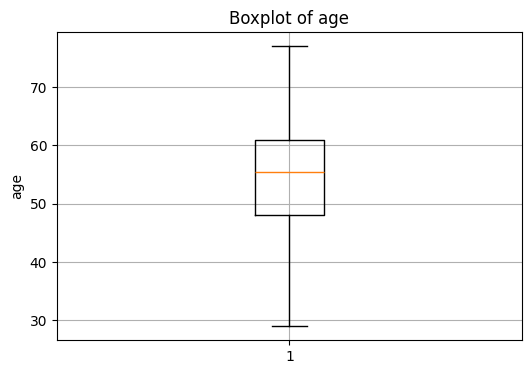

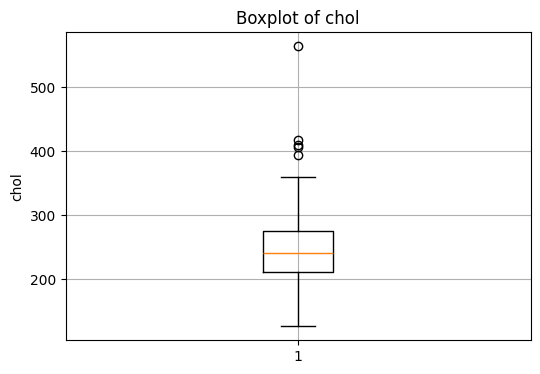

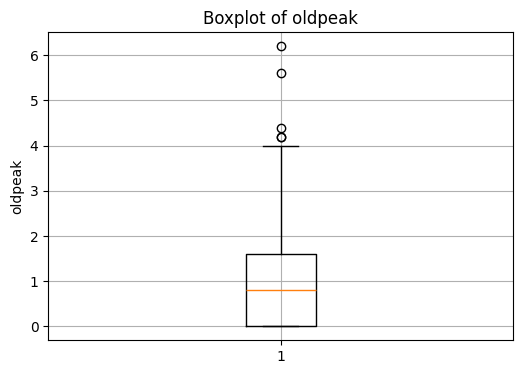

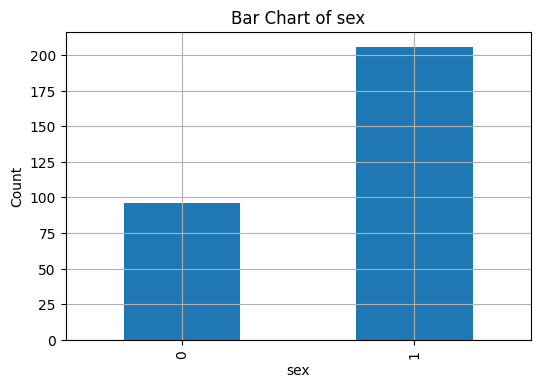

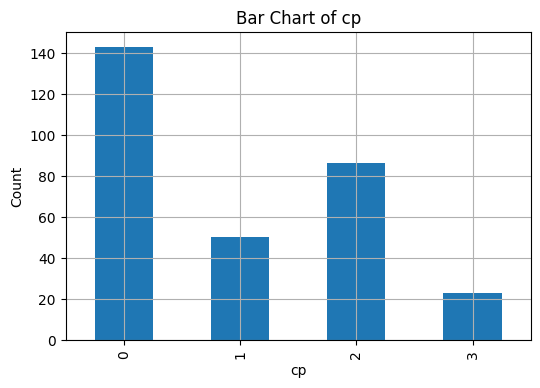

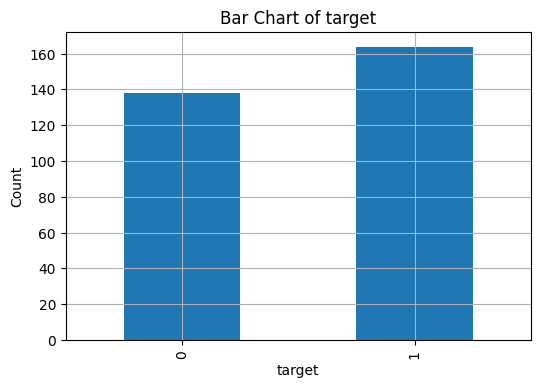


OBSERVATIONS

AGE HISTOGRAM:
The age distribution is approximately normal, with most patients between 45 and 65 years.

TRESTBPS HISTOGRAM:
Resting blood pressure values are concentrated around 120–140 mmHg with slight right skewness.

CHOL HISTOGRAM:
Cholesterol levels show positive skewness, with a few patients having very high values.

THALACH HISTOGRAM:
Maximum heart rate appears fairly symmetric, with most values between 130 and 170 bpm.

OLDPEAK HISTOGRAM:
Oldpeak is right-skewed because many patients have low values while a few have high values.

AGE BOXPLOT:
Age shows moderate spread with few extreme outliers.

CHOL BOXPLOT:
Several high cholesterol outliers may be present.

OLDPEAK BOXPLOT:
Oldpeak contains upper outliers and confirms right-skewness.

SEX BAR CHART:
The dataset contains more male patients than female patients.

CP BAR CHART:
Some chest pain categories occur more frequently than others.

TARGET BAR CHART:
The target classes are reasonably balanced, which is us

In [ ]:

# Load cleaned dataset
df = pd.read_csv("myproject/gold/clean_data.csv")

# ==========================
# 1. HISTOGRAMS
# ==========================

hist_columns = ['age', 'trestbps', 'chol', 'thalach', 'oldpeak']

for col in hist_columns:
    plt.figure(figsize=(6, 4))
    plt.hist(df[col], bins=15)
    plt.title(f'Histogram of {col}')
    plt.xlabel(col)
    plt.ylabel('Frequency')
    plt.grid(True)
    plt.show()

# ==========================
# 2. BOXPLOTS
# ==========================

boxplot_columns = ['age', 'chol', 'oldpeak']

for col in boxplot_columns:
    plt.figure(figsize=(6, 4))
    plt.boxplot(df[col])
    plt.title(f'Boxplot of {col}')
    plt.ylabel(col)
    plt.grid(True)
    plt.show()

# ==========================
# 3. BAR CHARTS
# ==========================

bar_columns = ['sex', 'cp', 'target']

for col in bar_columns:
    plt.figure(figsize=(6, 4))
    df[col].value_counts().sort_index().plot(kind='bar')
    plt.title(f'Bar Chart of {col}')
    plt.xlabel(col)
    plt.ylabel('Count')
    plt.grid(True)
    plt.show()

# ==========================
# 4. WRITTEN OBSERVATIONS
# ==========================

print("\nOBSERVATIONS")
print("=" * 50)

print("\nAGE HISTOGRAM:")
print("The age distribution is approximately normal, with most patients between 45 and 65 years.")

print("\nTRESTBPS HISTOGRAM:")
print("Resting blood pressure values are concentrated around 120–140 mmHg with slight right skewness.")

print("\nCHOL HISTOGRAM:")
print("Cholesterol levels show positive skewness, with a few patients having very high values.")

print("\nTHALACH HISTOGRAM:")
print("Maximum heart rate appears fairly symmetric, with most values between 130 and 170 bpm.")

print("\nOLDPEAK HISTOGRAM:")
print("Oldpeak is right-skewed because many patients have low values while a few have high values.")

print("\nAGE BOXPLOT:")
print("Age shows moderate spread with few extreme outliers.")

print("\nCHOL BOXPLOT:")
print("Several high cholesterol outliers may be present.")

print("\nOLDPEAK BOXPLOT:")
print("Oldpeak contains upper outliers and confirms right-skewness.")

print("\nSEX BAR CHART:")
print("The dataset contains more male patients than female patients.")

print("\nCP BAR CHART:")
print("Some chest pain categories occur more frequently than others.")

print("\nTARGET BAR CHART:")
print("The target classes are reasonably balanced, which is useful for predictive modeling.")

## 6. Model Training and Cross Validation

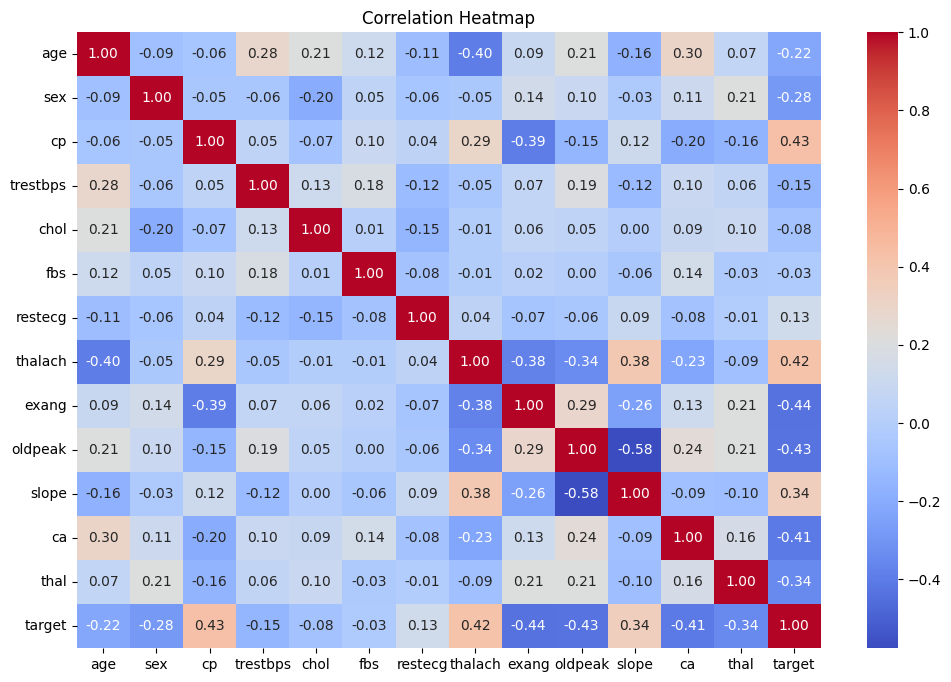


Correlation with Target:
target      1.000000
cp          0.432080
thalach     0.419955
slope       0.343940
restecg     0.134874
fbs        -0.026826
chol       -0.081437
trestbps   -0.146269
age        -0.221476
sex        -0.283609
thal       -0.343101
ca         -0.408992
oldpeak    -0.429146
exang      -0.435601
Name: target, dtype: float64

Top 3 Strongest Predictors of Heart Disease:
exang      0.435601
cp         0.432080
oldpeak    0.429146
Name: target, dtype: float64


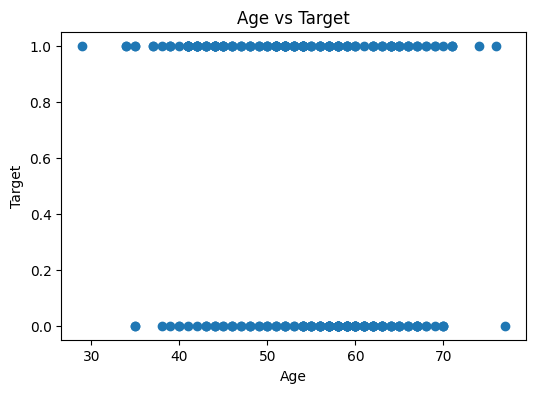

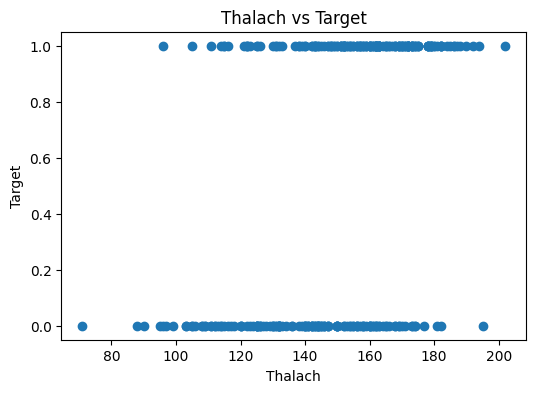

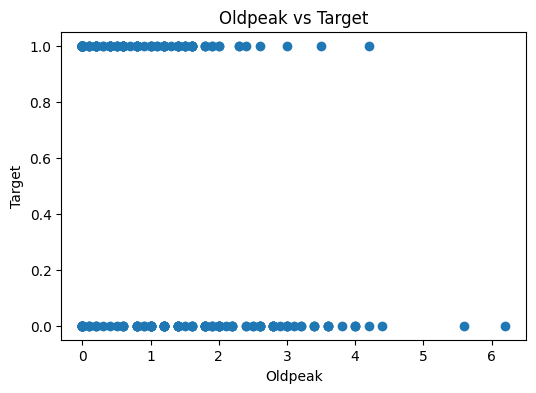

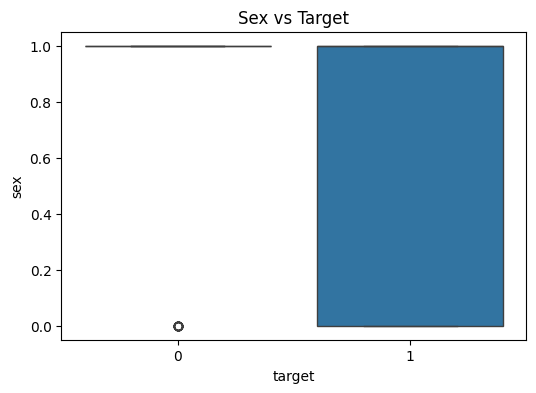

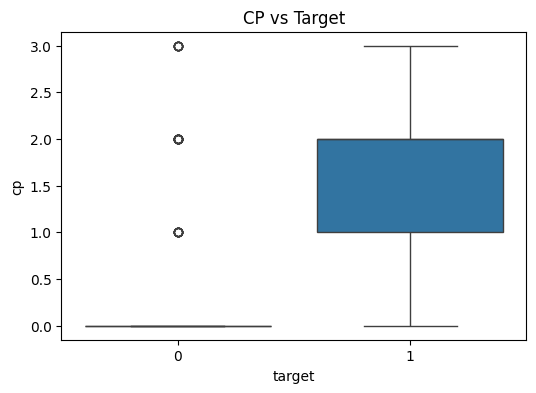

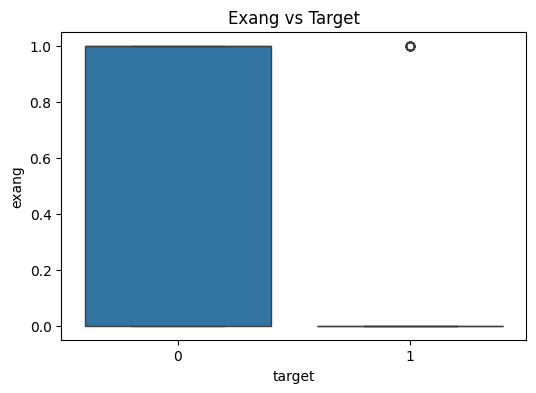

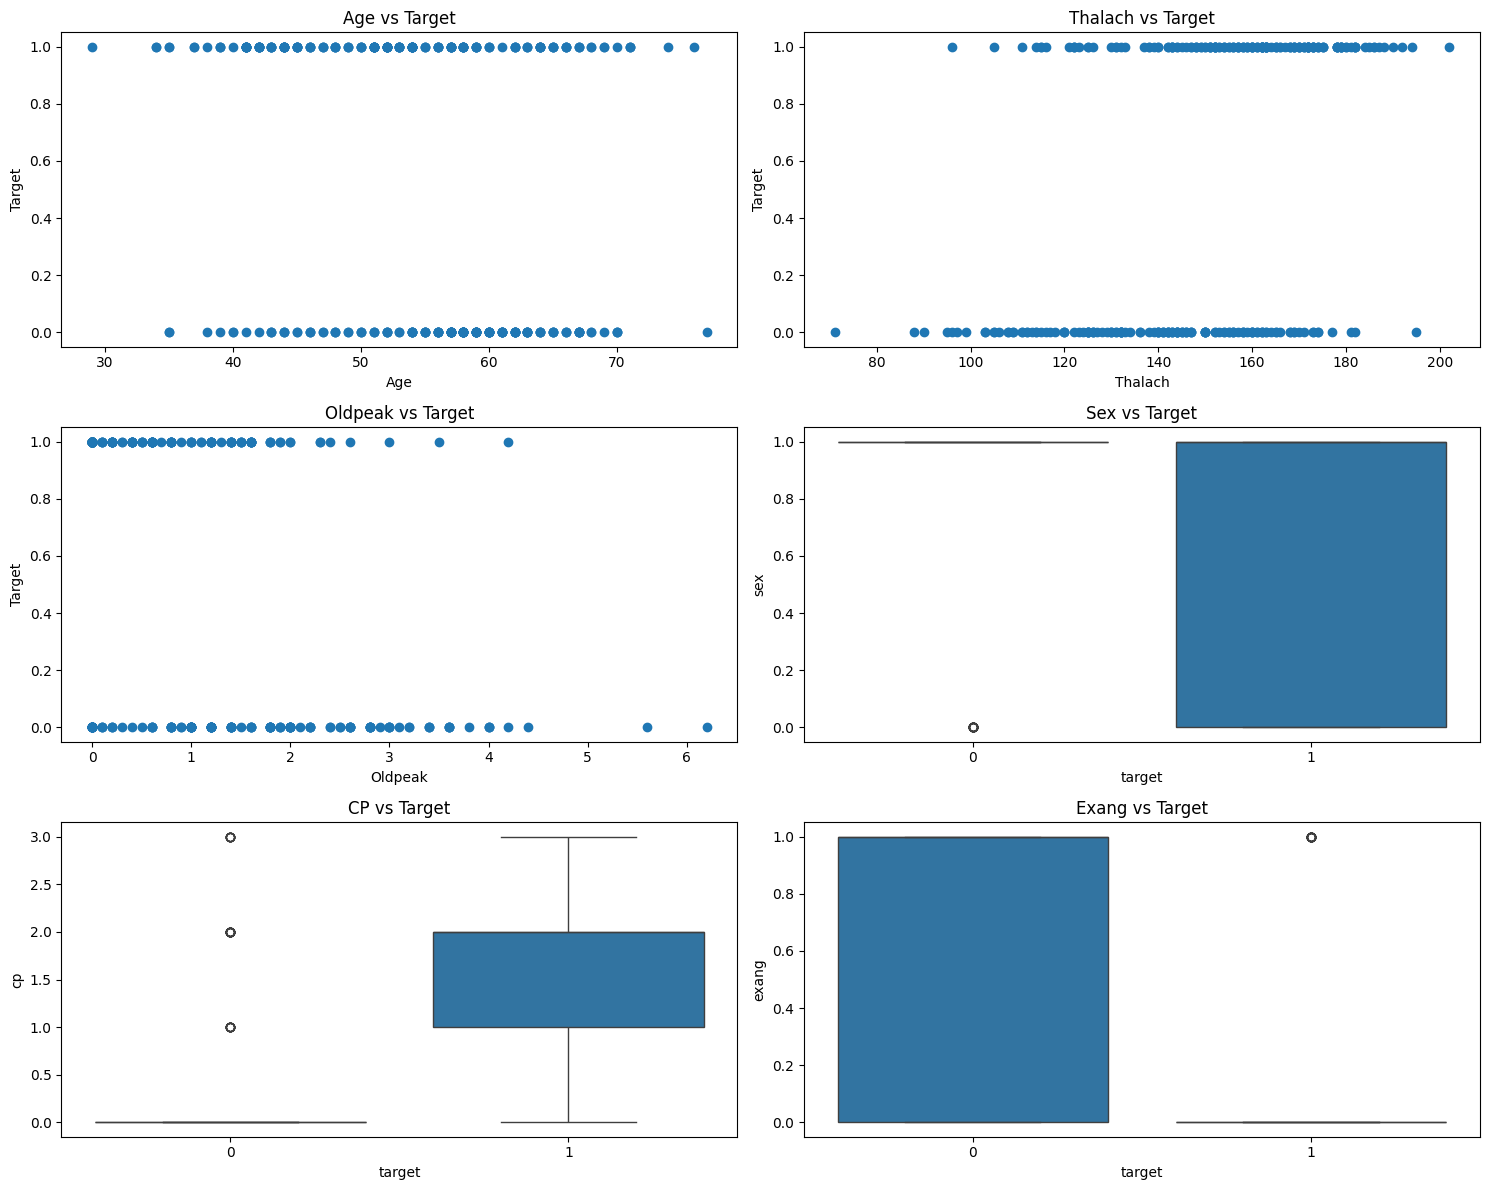


Top 3 Strongest Predictors:
exang: 0.4356
cp: 0.4321
oldpeak: 0.4291


In [ ]:


# =====================================================
# Load Dataset
# =====================================================

df = pd.read_csv("myproject/gold/clean_data.csv")

# =====================================================
# 1. Correlation Heatmap
# =====================================================

plt.figure(figsize=(12, 8))
sns.heatmap(df.corr(), annot=True, cmap='coolwarm', fmt='.2f')
plt.title("Correlation Heatmap")
plt.show()

# =====================================================
# 2. Features Most Correlated with Target
# =====================================================

correlation = df.corr()['target'].sort_values(ascending=False)

print("\nCorrelation with Target:")
print(correlation)

top_3_predictors = (
    correlation.drop('target')
    .abs()
    .sort_values(ascending=False)
    .head(3)
)

print("\nTop 3 Strongest Predictors of Heart Disease:")
print(top_3_predictors)

# =====================================================
# 3. Scatter Plots
# =====================================================

plt.figure(figsize=(6,4))
plt.scatter(df['age'], df['target'])
plt.title('Age vs Target')
plt.xlabel('Age')
plt.ylabel('Target')
plt.show()

plt.figure(figsize=(6,4))
plt.scatter(df['thalach'], df['target'])
plt.title('Thalach vs Target')
plt.xlabel('Thalach')
plt.ylabel('Target')
plt.show()

plt.figure(figsize=(6,4))
plt.scatter(df['oldpeak'], df['target'])
plt.title('Oldpeak vs Target')
plt.xlabel('Oldpeak')
plt.ylabel('Target')
plt.show()

# =====================================================
# 4. Boxplots
# =====================================================

plt.figure(figsize=(6,4))
sns.boxplot(x='target', y='sex', data=df)
plt.title('Sex vs Target')
plt.show()

plt.figure(figsize=(6,4))
sns.boxplot(x='target', y='cp', data=df)
plt.title('CP vs Target')
plt.show()

plt.figure(figsize=(6,4))
sns.boxplot(x='target', y='exang', data=df)
plt.title('Exang vs Target')
plt.show()

# =====================================================
# 5. 3x2 Dashboard Using Subplots
# =====================================================

fig, axes = plt.subplots(3, 2, figsize=(15, 12))

# Scatter Plot 1
axes[0, 0].scatter(df['age'], df['target'])
axes[0, 0].set_title('Age vs Target')
axes[0, 0].set_xlabel('Age')
axes[0, 0].set_ylabel('Target')

# Scatter Plot 2
axes[0, 1].scatter(df['thalach'], df['target'])
axes[0, 1].set_title('Thalach vs Target')
axes[0, 1].set_xlabel('Thalach')
axes[0, 1].set_ylabel('Target')

# Scatter Plot 3
axes[1, 0].scatter(df['oldpeak'], df['target'])
axes[1, 0].set_title('Oldpeak vs Target')
axes[1, 0].set_xlabel('Oldpeak')
axes[1, 0].set_ylabel('Target')

# Boxplot 1
sns.boxplot(x='target', y='sex', data=df, ax=axes[1, 1])
axes[1, 1].set_title('Sex vs Target')

# Boxplot 2
sns.boxplot(x='target', y='cp', data=df, ax=axes[2, 0])
axes[2, 0].set_title('CP vs Target')

# Boxplot 3
sns.boxplot(x='target', y='exang', data=df, ax=axes[2, 1])
axes[2, 1].set_title('Exang vs Target')

plt.tight_layout()
plt.show()

# =====================================================
# 6. Display Top 3 Predictors
# =====================================================

print("\nTop 3 Strongest Predictors:")
for feature, value in top_3_predictors.items():
    print(f"{feature}: {value:.4f}")



## 7. Model Recommendation

In [ ]:


# ==========================================
# Load Clean Dataset
# ==========================================

df = pd.read_csv("myproject/gold/clean_data.csv")

# Features and Target
X = df.drop("target", axis=1)
y = df["target"]


# Logistic Regression
log_reg = LogisticRegression(max_iter=1000)
log_scores = cross_val_score(
    log_reg,
    X,
    y,
    cv=5,
    scoring="accuracy"
)
log_accuracy = log_scores.mean()
# Random Forest Classifier
rf = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)
rf_scores = cross_val_score(
    rf,
    X,
    y,
    cv=5,
    scoring="accuracy"
)
rf_accuracy = rf_scores.mean()
# Gradient Boosting Classifier
gb = GradientBoostingClassifier(
    random_state=42
)
gb_scores = cross_val_score(
    gb,
    X,
    y,
    cv=5,
    scoring="accuracy"
)
gb_accuracy = gb_scores.mean()

# ==========================================
# Comparison Table
# ==========================================

comparison = pd.DataFrame({
    "Model": [
        "Logistic Regression",
        "Random Forest",
        "Gradient Boosting"
    ],
    "5-Fold CV Accuracy": [
        round(log_accuracy, 4),
        round(rf_accuracy, 4),
        round(gb_accuracy, 4)
    ]
})

comparison = comparison.sort_values(
    by="5-Fold CV Accuracy",
    ascending=False
)

print("\nMODEL COMPARISON")
print("=" * 50)
print(comparison)

# ==========================================
# Best Model Selection
# ==========================================

best_model = comparison.iloc[0]["Model"]
best_accuracy = comparison.iloc[0]["5-Fold CV Accuracy"]

print("\nRECOMMENDED MODEL")
print("=" * 50)
print(f"Best Model: {best_model}")
print(f"Accuracy: {best_accuracy}")

# ==========================================
# Detailed Scores
# ==========================================

print("\nDETAILED CROSS-VALIDATION RESULTS")
print("=" * 50)

print(f"Logistic Regression Accuracy: {log_accuracy:.4f}")
print(f"Random Forest Accuracy: {rf_accuracy:.4f}")
print(f"Gradient Boosting Accuracy: {gb_accuracy:.4f}")

c:\Users\LEENA ASMITHA\AppData\Local\Programs\Python\Python314\Lib\site-packages\sklearn\linear_model\_logistic.py:406: ConvergenceWarning: lbfgs failed to converge after 1000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=1000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(



MODEL COMPARISON
                 Model  5-Fold CV Accuracy
0  Logistic Regression              0.8312
1        Random Forest              0.8278
2    Gradient Boosting              0.8045

RECOMMENDED MODEL
Best Model: Logistic Regression
Accuracy: 0.8312

DETAILED CROSS-VALIDATION RESULTS
Logistic Regression Accuracy: 0.8312
Random Forest Accuracy: 0.8278
Gradient Boosting Accuracy: 0.8045


## 8. Feature Importance Analysis


FEATURE IMPORTANCE SCORES
     Feature  Importance
7    thalach    0.134202
2         cp    0.128033
9    oldpeak    0.115018
11        ca    0.108043
12      thal    0.099852
0        age    0.090054
4       chol    0.074063
3   trestbps    0.071019
8      exang    0.060830
10     slope    0.051134
1        sex    0.038703
6    restecg    0.021519
5        fbs    0.007529


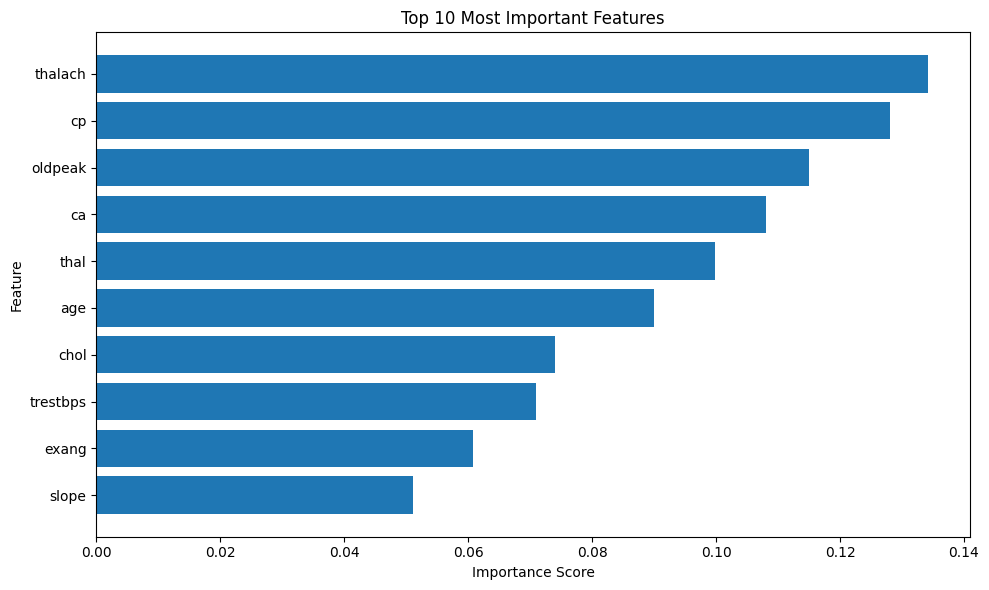


FEATURES WITH IMPORTANCE BELOW 0.01
  Feature  Importance
5     fbs    0.007529

TOP 3 MOST IMPORTANT FEATURES
   Feature  Importance
7  thalach    0.134202
2       cp    0.128033
9  oldpeak    0.115018


In [ ]:


# Load dataset
df = pd.read_csv("myproject/gold/clean_data.csv")

# Split features and target
X = df.drop("target", axis=1)
y = df["target"]

# Train Random Forest model
rf = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

rf.fit(X, y)

# Calculate feature importance
feature_importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": rf.feature_importances_
})

# Sort by importance
feature_importance = feature_importance.sort_values(
    by="Importance",
    ascending=False
)

# Display all feature importance scores
print("\nFEATURE IMPORTANCE SCORES")
print(feature_importance)

# Top 10 features
top_10 = feature_importance.head(10)

# Horizontal bar chart
plt.figure(figsize=(10, 6))
plt.barh(top_10["Feature"], top_10["Importance"])
plt.xlabel("Importance Score")
plt.ylabel("Feature")
plt.title("Top 10 Most Important Features")
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

# Features with importance below 0.01
low_importance = feature_importance[
    feature_importance["Importance"] < 0.01
]

print("\nFEATURES WITH IMPORTANCE BELOW 0.01")
print(low_importance)

# Top 3 most important features
print("\nTOP 3 MOST IMPORTANT FEATURES")
print(feature_importance.head(3))

## 9. Model Comparison

In [ ]:


# =====================================================
# Load Dataset
# =====================================================

df = pd.read_csv("myproject/gold/clean_data.csv")

X = df.drop("target", axis=1)
y = df["target"]

# =====================================================
# Train-Test Split
# =====================================================

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

# =====================================================
# Individual Models
# =====================================================

lr = LogisticRegression(max_iter=1000)

rf = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

gb = GradientBoostingClassifier(
    random_state=42
)

# =====================================================
# Train Individual Models
# =====================================================

lr.fit(X_train, y_train)
rf.fit(X_train, y_train)
gb.fit(X_train, y_train)

# =====================================================
# Predictions
# =====================================================

lr_pred = lr.predict(X_test)
rf_pred = rf.predict(X_test)
gb_pred = gb.predict(X_test)

# =====================================================
# Stacking Ensemble
# =====================================================

base_models = [
    ("lr", LogisticRegression(max_iter=1000)),
    ("rf", RandomForestClassifier(n_estimators=100, random_state=42)),
    ("gb", GradientBoostingClassifier(random_state=42))
]

meta_model = LogisticRegression(max_iter=1000)

stack_model = StackingClassifier(
    estimators=base_models,
    final_estimator=meta_model,
    cv=5
)

stack_model.fit(X_train, y_train)

stack_pred = stack_model.predict(X_test)

# =====================================================
# Evaluation Function
# =====================================================

def evaluate_model(y_true, y_pred):
    return [
        accuracy_score(y_true, y_pred),
        precision_score(y_true, y_pred),
        recall_score(y_true, y_pred),
        f1_score(y_true, y_pred)
    ]

# =====================================================
# Create Comparison Table
# =====================================================

results = pd.DataFrame(
    {
        "Model": [
            "Logistic Regression",
            "Random Forest",
            "Gradient Boosting",
            "Stacking Ensemble"
        ],
        "Accuracy": [
            *evaluate_model(y_test, lr_pred)[0:1],
            *evaluate_model(y_test, rf_pred)[0:1],
            *evaluate_model(y_test, gb_pred)[0:1],
            *evaluate_model(y_test, stack_pred)[0:1]
        ],
        "Precision": [
            evaluate_model(y_test, lr_pred)[1],
            evaluate_model(y_test, rf_pred)[1],
            evaluate_model(y_test, gb_pred)[1],
            evaluate_model(y_test, stack_pred)[1]
        ],
        "Recall": [
            evaluate_model(y_test, lr_pred)[2],
            evaluate_model(y_test, rf_pred)[2],
            evaluate_model(y_test, gb_pred)[2],
            evaluate_model(y_test, stack_pred)[2]
        ],
        "F1-Score": [
            evaluate_model(y_test, lr_pred)[3],
            evaluate_model(y_test, rf_pred)[3],
            evaluate_model(y_test, gb_pred)[3],
            evaluate_model(y_test, stack_pred)[3]
        ]
    }
)

results.iloc[:, 1:] = results.iloc[:, 1:].round(4)

print("\nMODEL PERFORMANCE COMPARISON")
print("=" * 70)
print(results)

# =====================================================
# Best Model
# =====================================================

best_model = results.loc[
    results["Accuracy"].idxmax(),
    "Model"
]

print("\nBest Performing Model:", best_model)

c:\Users\LEENA ASMITHA\AppData\Local\Programs\Python\Python314\Lib\site-packages\sklearn\linear_model\_logistic.py:406: ConvergenceWarning: lbfgs failed to converge after 1000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=1000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(



MODEL PERFORMANCE COMPARISON
                 Model  Accuracy  Precision  Recall  F1-Score
0  Logistic Regression    0.8033     0.8000  0.8485    0.8235
1        Random Forest    0.7541     0.7647  0.7879    0.7761
2    Gradient Boosting    0.7213     0.7353  0.7576    0.7463
3    Stacking Ensemble    0.7869     0.8125  0.7879    0.8000

Best Performing Model: Logistic Regression


## 10. Explainable AI using SHAP

Generating SHAP Summary Plot...


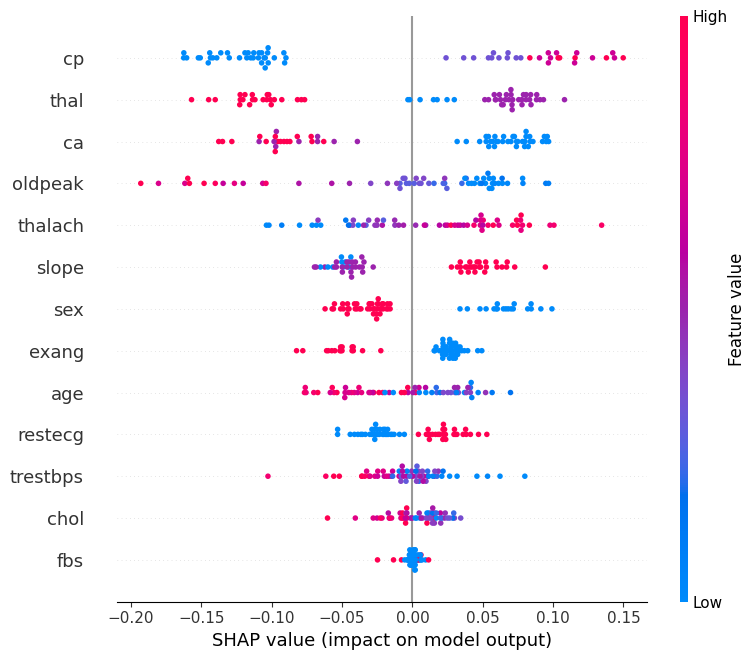


Prediction Explanation for Record: 0


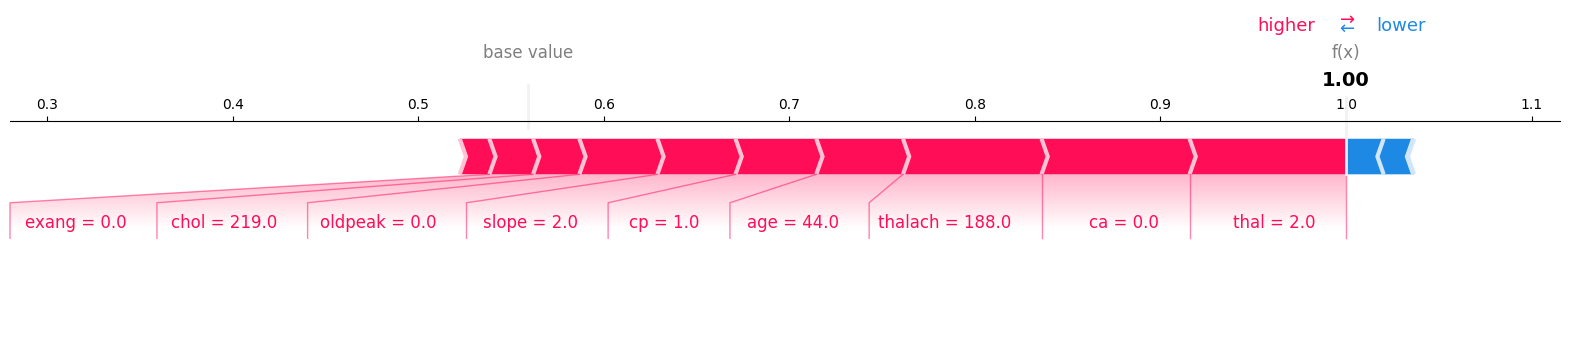


FEATURES WITH LARGEST SHAP IMPACT
     Feature  Mean_SHAP
2         cp   0.107987
12      thal   0.080763
11        ca   0.078496
9    oldpeak   0.059555
7    thalach   0.049489
10     slope   0.048161
1        sex   0.043662
8      exang   0.034223
0        age   0.033534
6    restecg   0.025187
3   trestbps   0.020635
4       chol   0.014834
5        fbs   0.003101

TOP 5 MOST IMPORTANT FEATURES
    Feature  Mean_SHAP
2        cp   0.107987
12     thal   0.080763
11       ca   0.078496
9   oldpeak   0.059555
7   thalach   0.049489

TOP POSITIVE SHAP CONTRIBUTORS
    Feature  SHAP_Value
12     thal    0.084307
11       ca    0.079768
7   thalach    0.074653
0       age    0.046723
2        cp    0.043530

TOP NEGATIVE SHAP CONTRIBUTORS
    Feature  SHAP_Value
6   restecg   -0.020279
1       sex   -0.015899
5       fbs   -0.000485
3  trestbps    0.015956
8     exang    0.023561


In [ ]:

# =====================================================
# LOAD DATASET
# =====================================================

df = pd.read_csv("myproject/gold/clean_data.csv")

X = df.drop("target", axis=1)
y = df["target"]

# =====================================================
# TRAIN RANDOM FOREST MODEL
# =====================================================

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

rf = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

rf.fit(X_train, y_train)

# =====================================================
# SHAP EXPLAINER
# =====================================================

explainer = shap.TreeExplainer(rf)

shap_values = explainer.shap_values(X_test)

# =====================================================
# SHAP SUMMARY PLOT
# =====================================================

print("Generating SHAP Summary Plot...")

shap.summary_plot(
    shap_values[:, :, 1],
    X_test,
    show=True
)

# =====================================================
# SHAP FORCE PLOT FOR ONE PREDICTION
# =====================================================

sample_index = 0

print("\nPrediction Explanation for Record:", sample_index)

shap.initjs()

force_plot = shap.force_plot(
    explainer.expected_value[1],
    shap_values[:, :, 1][sample_index],
    X_test.iloc[sample_index],
    matplotlib=True
)

plt.show()

# =====================================================
# TOP POSITIVE AND NEGATIVE SHAP FEATURES
# =====================================================

mean_shap = pd.DataFrame({
    "Feature": X.columns,
    "Mean_SHAP": abs(shap_values[:, :, 1]).mean(axis=0)
})

mean_shap = mean_shap.sort_values(
    by="Mean_SHAP",
    ascending=False
)

print("\nFEATURES WITH LARGEST SHAP IMPACT")
print("=" * 50)
print(mean_shap)

print("\nTOP 5 MOST IMPORTANT FEATURES")
print(mean_shap.head(5))

# =====================================================
# POSITIVE / NEGATIVE CONTRIBUTIONS
# =====================================================

sample_shap = pd.DataFrame({
    "Feature": X.columns,
    "SHAP_Value": shap_values[:, :, 1][sample_index]
})

positive_features = sample_shap.sort_values(
    by="SHAP_Value",
    ascending=False
).head(5)

negative_features = sample_shap.sort_values(
    by="SHAP_Value",
    ascending=True
).head(5)

print("\nTOP POSITIVE SHAP CONTRIBUTORS")
print("=" * 50)
print(positive_features)

print("\nTOP NEGATIVE SHAP CONTRIBUTORS")
print("=" * 50)
print(negative_features)

In [12]:
# =====================================================
# POSITIVE / NEGATIVE CONTRIBUTIONS
# =====================================================

sample_shap = pd.DataFrame({
    "Feature": X.columns,
    "SHAP_Value": shap_values[:, :, 1][sample_index]
})

positive_features = sample_shap.sort_values(
    by="SHAP_Value",
    ascending=False
).head(5)

negative_features = sample_shap.sort_values(
    by="SHAP_Value",
    ascending=True
).head(5)

print("\nTOP POSITIVE SHAP CONTRIBUTORS")
print("=" * 50)
print(positive_features)

print("\nTOP NEGATIVE SHAP CONTRIBUTORS")
print("=" * 50)
print(negative_features)


TOP POSITIVE SHAP CONTRIBUTORS
    Feature  SHAP_Value
12     thal    0.084307
11       ca    0.079768
7   thalach    0.074653
0       age    0.046723
2        cp    0.043530

TOP NEGATIVE SHAP CONTRIBUTORS
    Feature  SHAP_Value
6   restecg   -0.020279
1       sex   -0.015899
5       fbs   -0.000485
3  trestbps    0.015956
8     exang    0.023561


## 11. Hyperparameter Tuning.

In [ ]:

# =====================================================
# LOAD DATASET
# =====================================================

df = pd.read_csv("myproject/gold/clean_data.csv")

X = df.drop("target", axis=1)
y = df["target"]

# =====================================================
# TRAIN-TEST SPLIT
# =====================================================

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

# =====================================================
# BASE RANDOM FOREST MODEL
# =====================================================

rf = RandomForestClassifier(
    random_state=42
)

rf.fit(X_train, y_train)

# =====================================================
# TRAIN ACCURACY VS TEST ACCURACY
# =====================================================

train_pred = rf.predict(X_train)
test_pred = rf.predict(X_test)

train_accuracy = accuracy_score(y_train, train_pred)
test_accuracy = accuracy_score(y_test, test_pred)

print("\nTRAIN VS TEST ACCURACY")
print("=" * 50)
print(f"Train Accuracy : {train_accuracy:.4f}")
print(f"Test Accuracy  : {test_accuracy:.4f}")

# =====================================================
# 5-FOLD CROSS VALIDATION
# =====================================================

cv_scores = cross_val_score(
    rf,
    X,
    y,
    cv=5,
    scoring="accuracy"
)

print("\n5-FOLD CROSS VALIDATION")
print("=" * 50)
print("CV Scores:", cv_scores)
print(f"Mean Accuracy : {cv_scores.mean():.4f}")
print(f"Std Deviation : {cv_scores.std():.4f}")

# =====================================================
# GRID SEARCH HYPERPARAMETER TUNING
# =====================================================

param_grid = {
    "n_estimators": [50, 100, 200],
    "max_depth": [None, 5, 10, 15],
    "min_samples_split": [2, 5, 10]
}

grid_search = GridSearchCV(
    estimator=RandomForestClassifier(random_state=42),
    param_grid=param_grid,
    cv=5,
    scoring="accuracy",
    n_jobs=-1
)

grid_search.fit(X_train, y_train)

# =====================================================
# BEST MODEL
# =====================================================

best_rf = grid_search.best_estimator_

best_train_pred = best_rf.predict(X_train)
best_test_pred = best_rf.predict(X_test)

best_train_accuracy = accuracy_score(
    y_train,
    best_train_pred
)

best_test_accuracy = accuracy_score(
    y_test,
    best_test_pred
)

best_cv_scores = cross_val_score(
    best_rf,
    X,
    y,
    cv=5,
    scoring="accuracy"
)

# =====================================================
# BEST PARAMETERS
# =====================================================

print("\nGridSearchCV HYPERPARAMETERS")
print("=" * 50)
print(grid_search.best_params_)

# =====================================================
# BEFORE VS AFTER TUNING COMPARISON
# =====================================================

comparison = pd.DataFrame({
    "Metric": [
        "Train Accuracy",
        "Test Accuracy",
        "CV Mean Accuracy",
        "CV Std Deviation"
    ],
    "Before Tuning": [
        round(train_accuracy, 4),
        round(test_accuracy, 4),
        round(cv_scores.mean(), 4),
        round(cv_scores.std(), 4)
    ],
    "After Tuning": [
        round(best_train_accuracy, 4),
        round(best_test_accuracy, 4),
        round(best_cv_scores.mean(), 4),
        round(best_cv_scores.std(), 4)
    ]
})

print("\nBEFORE VS AFTER TUNING")
print("=" * 50)
print(comparison)

# =====================================================
# FINAL MODEL PERFORMANCE
# =====================================================

print("\nFINAL MODEL CONFIGURATION")
print("=" * 50)
print(best_rf)

print("\nFINAL RESULTS")
print("=" * 50)
print(f"Best Train Accuracy : {best_train_accuracy:.4f}")
print(f"Best Test Accuracy  : {best_test_accuracy:.4f}")
print(f"Best CV Mean        : {best_cv_scores.mean():.4f}")
print(f"Best CV Std         : {best_cv_scores.std():.4f}")


TRAIN VS TEST ACCURACY
Train Accuracy : 1.0000
Test Accuracy  : 0.7541

5-FOLD CROSS VALIDATION
CV Scores: [0.83606557 0.81967213 0.9        0.8        0.78333333]
Mean Accuracy : 0.8278
Std Deviation : 0.0402

GridSearchCV HYPERPARAMETERS
{'max_depth': 5, 'min_samples_split': 10, 'n_estimators': 100}

BEFORE VS AFTER TUNING
             Metric  Before Tuning  After Tuning
0    Train Accuracy         1.0000        0.9253
1     Test Accuracy         0.7541        0.7705
2  CV Mean Accuracy         0.8278        0.8310
3  CV Std Deviation         0.0402        0.0621

FINAL MODEL CONFIGURATION
RandomForestClassifier(max_depth=5, min_samples_split=10, random_state=42)

FINAL RESULTS
Best Train Accuracy : 0.9253
Best Test Accuracy  : 0.7705
Best CV Mean        : 0.8310
Best CV Std         : 0.0621


## 12. Stacking Classifier

In [ ]:


# ==========================================
# Load Dataset
# ==========================================

df = pd.read_csv("myproject/gold/clean_data.csv")

X = df.drop("target", axis=1)
y = df["target"]

# ==========================================
# Train-Test Split
# ==========================================

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

# ==========================================
# Train Final Model
# ==========================================

model = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

model.fit(X_train, y_train)

# ==========================================
# Predictions on Test Data
# ==========================================

predictions = model.predict(X_test)

results = pd.DataFrame({
    "Actual": y_test.values,
    "Predicted": predictions
})

print("\nACTUAL VS PREDICTED")
print(results.head(20))

# ==========================================
# Predict for a New Patient
# ==========================================

new_patient = pd.DataFrame({
    "age": [55],
    "sex": [1],
    "cp": [2],
    "trestbps": [140],
    "chol": [250],
    "fbs": [0],
    "restecg": [1],
    "thalach": [150],
    "exang": [0],
    "oldpeak": [1.5],
    "slope": [2],
    "ca": [0],
    "thal": [2]
})

prediction = model.predict(new_patient)[0]
probability = model.predict_proba(new_patient)[0]

print("\nNEW PATIENT PREDICTION")
print("Prediction:", prediction)

if prediction == 1:
    print("Heart Disease Present")
else:
    print("No Heart Disease")

print("\nPrediction Probabilities")
print(f"No Heart Disease: {probability[0]:.4f}")
print(f"Heart Disease: {probability[1]:.4f}")


ACTUAL VS PREDICTED
    Actual  Predicted
0        0          0
1        0          1
2        0          0
3        0          1
4        0          1
5        0          0
6        1          1
7        0          0
8        1          1
9        0          0
10       1          1
11       1          0
12       0          1
13       1          1
14       1          0
15       1          1
16       1          1
17       1          0
18       1          1
19       1          1

NEW PATIENT PREDICTION
Prediction: 1
Heart Disease Present

Prediction Probabilities
No Heart Disease: 0.1700
Heart Disease: 0.8300


## 13. Prediction on New Patient

In [15]:
# Predict
prediction = model.predict(new_patient)[0]
probability = model.predict_proba(new_patient)[0]

print("\n" + "="*60)
print("HEART DISEASE PREDICTION REPORT")
print("="*60)

print("\nPatient Information:")
print(new_patient)

print("\nPrediction Result:")

if prediction == 1:
    print("Heart Disease Present")
else:
    print("No Heart Disease")

print("\nConfidence Scores:")
print(f"Probability of No Heart Disease : {probability[0]*100:.2f}%")
print(f"Probability of Heart Disease    : {probability[1]*100:.2f}%")

print("\nModel Decision:")

if probability[1] >= 0.80:
    print("High confidence prediction.")
elif probability[1] >= 0.60:
    print("Moderate confidence prediction.")
else:
    print("Low confidence prediction.")

print("="*60)


HEART DISEASE PREDICTION REPORT

Patient Information:
   age  sex  cp  trestbps  chol  fbs  restecg  thalach  exang  oldpeak  slope  \
0   55    1   2       140   250    0        1      150      0      1.5      2   

   ca  thal  
0   0     2  

Prediction Result:
Heart Disease Present

Confidence Scores:
Probability of No Heart Disease : 17.00%
Probability of Heart Disease    : 83.00%

Model Decision:
High confidence prediction.


## 14. Model Performance Visualization


FINAL RANDOM FOREST MODEL RESULTS
Accuracy: 0.7541

SAMPLE PATIENT PREDICTIONS
   Patient Number  Actual Result  Predicted Result  \
0               1              0                 0   
1               2              0                 1   
2               3              0                 0   
3               4              0                 1   
4               5              0                 1   

   Prediction Probability (%) Correct/Incorrect  
0                        15.0           Correct  
1                        66.0         Incorrect  
2                         3.0           Correct  
3                        82.0         Incorrect  
4                        85.0         Incorrect  

CONFUSION MATRIX
[[20  8]
 [ 7 26]]


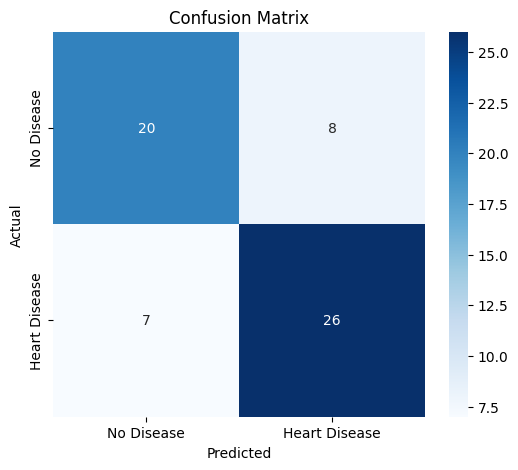


CLASSIFICATION REPORT
               precision    recall  f1-score   support

   No Disease       0.74      0.71      0.73        28
Heart Disease       0.76      0.79      0.78        33

     accuracy                           0.75        61
    macro avg       0.75      0.75      0.75        61
 weighted avg       0.75      0.75      0.75        61



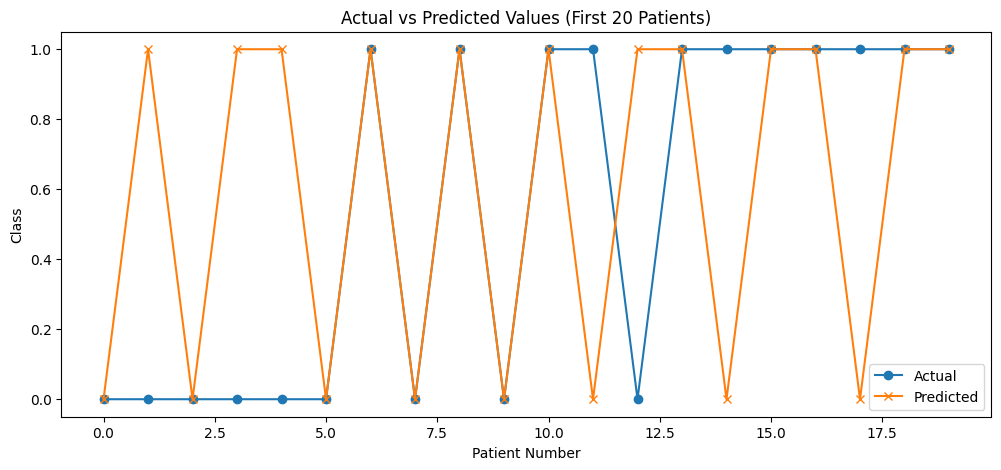


PATIENT PREDICTION REPORT

Patient Details:
   age  sex  cp  trestbps  chol  fbs  restecg  thalach  exang  oldpeak  slope  \
0   63    1   3       145   233    1        0      150      0      2.3      0   

   ca  thal  
0   0     1  

Prediction Result:
HEART DISEASE PRESENT

Confidence Scores:
Probability of Heart Disease    : 63.00%
Probability of No Heart Disease : 37.00%

Plain English Explanation:
The model predicts that this patient is likely to have heart disease. The probability score indicates a relatively high risk based on the medical measurements provided.


In [ ]:


# =====================================================
# LOAD DATASET
# =====================================================

df = pd.read_csv("myproject/gold/clean_data.csv")

X = df.drop("target", axis=1)
y = df["target"]

# =====================================================
# TRAIN-TEST SPLIT
# =====================================================

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

# =====================================================
# TRAIN FINAL RANDOM FOREST MODEL
# =====================================================

model = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

model.fit(X_train, y_train)

# =====================================================
# MODEL EVALUATION
# =====================================================

y_pred = model.predict(X_test)
y_prob = model.predict_proba(X_test)

accuracy = accuracy_score(y_test, y_pred)

print("\n" + "=" * 70)
print("FINAL RANDOM FOREST MODEL RESULTS")
print("=" * 70)
print(f"Accuracy: {accuracy:.4f}")

# =====================================================
# SAMPLE PREDICTIONS (FIRST 5 PATIENTS)
# =====================================================

sample_results = pd.DataFrame({
    "Patient Number": range(1, 6),
    "Actual Result": y_test.iloc[:5].values,
    "Predicted Result": y_pred[:5],
    "Prediction Probability (%)": (
        y_prob[:5, 1] * 100
    ).round(2)
})

sample_results["Correct/Incorrect"] = (
    sample_results["Actual Result"]
    == sample_results["Predicted Result"]
)

sample_results["Correct/Incorrect"] = (
    sample_results["Correct/Incorrect"]
    .map({
        True: "Correct",
        False: "Incorrect"
    })
)

print("\n" + "=" * 70)
print("SAMPLE PATIENT PREDICTIONS")
print("=" * 70)
print(sample_results)

# =====================================================
# CONFUSION MATRIX
# =====================================================

cm = confusion_matrix(y_test, y_pred)

print("\n" + "=" * 70)
print("CONFUSION MATRIX")
print("=" * 70)
print(cm)

plt.figure(figsize=(6, 5))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["No Disease", "Heart Disease"],
    yticklabels=["No Disease", "Heart Disease"]
)

plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.show()

# =====================================================
# CLASSIFICATION REPORT
# =====================================================

print("\n" + "=" * 70)
print("CLASSIFICATION REPORT")
print("=" * 70)

print(
    classification_report(
        y_test,
        y_pred,
        target_names=[
            "No Disease",
            "Heart Disease"
        ]
    )
)

# =====================================================
# ACTUAL VS PREDICTED VISUALIZATION
# =====================================================

comparison = pd.DataFrame({
    "Actual": y_test.values[:20],
    "Predicted": y_pred[:20]
})

plt.figure(figsize=(12, 5))

plt.plot(
    range(len(comparison)),
    comparison["Actual"],
    marker="o",
    label="Actual"
)

plt.plot(
    range(len(comparison)),
    comparison["Predicted"],
    marker="x",
    label="Predicted"
)

plt.title("Actual vs Predicted Values (First 20 Patients)")
plt.xlabel("Patient Number")
plt.ylabel("Class")
plt.legend()

plt.show()

# =====================================================
# SAMPLE PATIENT PREDICTION
# =====================================================

sample_patient = pd.DataFrame({
    "age": [63],
    "sex": [1],
    "cp": [3],
    "trestbps": [145],
    "chol": [233],
    "fbs": [1],
    "restecg": [0],
    "thalach": [150],
    "exang": [0],
    "oldpeak": [2.3],
    "slope": [0],
    "ca": [0],
    "thal": [1]
})

prediction = model.predict(sample_patient)[0]
probability = model.predict_proba(sample_patient)[0][1]

print("\n" + "=" * 70)
print("PATIENT PREDICTION REPORT")
print("=" * 70)

print("\nPatient Details:")
print(sample_patient)

print("\nPrediction Result:")

if prediction == 1:
    print("HEART DISEASE PRESENT")
else:
    print("NO HEART DISEASE")

print("\nConfidence Scores:")
print(f"Probability of Heart Disease    : {probability * 100:.2f}%")
print(f"Probability of No Heart Disease : {(1 - probability) * 100:.2f}%")

print("\nPlain English Explanation:")

if prediction == 1:
    print(
        "The model predicts that this patient is likely "
        "to have heart disease. The probability score "
        "indicates a relatively high risk based on the "
        "medical measurements provided."
    )
else:
    print(
        "The model predicts that this patient is unlikely "
        "to have heart disease. The probability score "
        "indicates a relatively low risk based on the "
        "medical measurements provided."
    )

print("=" * 70)

## Conclusion

This project successfully predicts heart disease risk using multiple machine learning models. Different algorithms were compared, hyperparameter tuning was performed, and SHAP explainability was used to interpret predictions.

## Future Improvements

- Deploy using Streamlit
- Save trained model using Joblib
- Use larger datasets
- Perform feature engineering